---
title: "2D Simulation of Ground Impedance and Airborne Tipper Data"
authors:
  - id: devincowan
---

```{admonition} Introductory notebook
:class: hint
This tutorial teaches basic functionality within SimPEG and is a good entry point for new users.
```

```{admonition} Light-weight notebook
:class: hint
This tutorial requires minimal computational resources and can be executed quickly in the background while other computer processes are running.
```

**Keywords:** NSEM, forward simulation, 2D simulation.

</br>

**Summary:** In this tutorial, we use the module [simpeg.electromagnetics.natural_source](xref:simpeg#simpeg.electromagnetics.natural_source) to simulate ground magnetotelluric and airborne tipper data for a 2D problem geometry.

**Learning Objectives:**

- The fundamentals of simulating NSEM data with SimPEG.
- The data convention SimPEG uses for NSEM data.
- Simulating data for the TE and TM modes.

:::{warning} Warning: SimPEG NSEM data convention!
SimPEG uses a universally right-handed coordinate system with X = Easting, Y = Northing and Z positive upward, and a $+i\omega t$ Fourier convention. This in contrast to the Northing-Easting-Down convention that is commonly adopted by the NSEM community.
:::

## Import Modules

Here, we import all of the functionality required to run the notebook for the tutorial exercise. All of the functionality specific to NSEM is imported from [simpeg.electromagnetics.natural_source](xref:simpeg#simpeg.electromagnetics.natural_source). To generate the mesh, we use the [discretize](https://discretize.simpeg.xyz/en/main) package.
We also import some useful utility functions from [simpeg.utils](xref:simpeg#simpeg.utils).

In [1]:
# SimPEG functionality
import simpeg.electromagnetics.natural_source as nsem
from simpeg.utils import (
    model_builder, get_default_solver, shift_to_discrete_topography
)
from simpeg import maps, data

# discretize functionality
from discretize import TreeMesh, TensorMesh
from discretize.utils import active_from_xyz

# Common Python functionality
import os
import numpy as np
from scipy.interpolate import interp1d
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

mpl.rcParams.update({"font.size": 16})  # default font size

write_output = False  # Optional

## Define the Problem Geometry

### Topography

For a 2D simulation, topography is defined as an (N, 2) [numpy.ndarray](xref:numpy#numpy.ndarray), where the first coordinate represent along-line position and the second coordinate represents the vertical position. Here, we define the 2D topography used for the simulation.

**For the tutorial,** we consider flat topography at an elevation of 200 m. However the notebook has been generalized to allow a user-defined topography.

:::{attention} Attention: simulations with topography
Simulating NSEM data in the presence of significant topography on structured meshes (tree or tensor) can introduce problematic numerical error. Strategies for overcoming this obstacle are being investigated; e.g. allowing NSEM simulation for unstructured meshes (e.g. triangular, tetrahedral).
:::

In [2]:
# Along-line locations
x_topo = np.linspace(-8000, 8000, 501)

# Topography
z_topo = 200 * np.ones_like(x_topo)

# Define full 2D topography
topo_2d = np.c_[x_topo, z_topo]

### Define Conductivity Values

Here, we define the conductivities of the structures we are modeling, along with some basic geometric parameters.
We do this early in the tutorial since the generation of a suitable mesh for NSEM depends on a-priori knowledge of the subsurface conductivity distribution.

**For the tutorial,** the Earth consists of a non-conductive (1e-3 S/m) horizontal layer over a more conductive basement (1e-2 S/m). In the top layer, there is a conductive block (1e-1 S/m).

:::{attention} Attention: air cell conductivities/resistivities
Note that air is defined as having a conductivity of 1e-8 S/m and not 0!!! This is necessary to ensure the linear system being solved is well-conditionned. If working with resistivity, the air cells would be given a value of 1e8 $\Omega m$.
:::

In [3]:
# Conductivities
air_conductivity = 1e-8
host_conductivity = 1e-3
basement_conductivity = 1e-2
block_conductivity = 1e-1

# Geometry parameters
block_corner_1 = np.r_[-200.0, -360.0]
block_corner_2 = np.r_[200., -40.]
basement_elevation = -600

### Survey Geometry

Here, we define the survey geometry (e.g. locations, frequencies) used for the simulation.
This information is necessary for generating a suitable mesh, which is carried out in the following section.
At this time, however, we do not construct the SimPEG objects representing receivers, sources and the survey.
Reasons for this will be apparent later in the tutorial.

**For this tutorial**, we simulate the impedances and tippers that produce anomalies due to 2D structure:

* $Z_{xy}$ impedances
* $Z_{yx}$ impedances
* $T_{zx}$ tippers

MT-impedance data are simulated on the Earth's surface at 7 logarithmically spaced frequencies between 10 Hz and 100 Hz. The spacing between Ground-MT stations is 100 m.
Airborne tipper data are simulated at 6 frequencies between 30 Hz and 720 Hz. The station spacing for the tipper data is 50 m and the flight height is 40 m.
The tipper survey uses a ZTEM configuration where a surface base station is located on the surface at x = -4000 m.

In [4]:
# Define linear interpolation function for elevation.
interp_fun = interp1d(x_topo, z_topo)

In [5]:
# Frequencies and locations for ground MT stations
frequencies_mt = np.logspace(1, 3, 7)
locations_x_mt = np.arange(-3000., 3001., 200.)
locations_z_mt = interp_fun(locations_x_mt)  # place on surface
locations_mt = np.c_[locations_x_mt, locations_z_mt]

# Frequencies and airborne locations for ZTEM survey
frequencies_ztem = np.r_[30., 45., 90., 180., 360., 720.]
flight_height = 40.
locations_x_ztem = np.arange(-3000., 3001., 50)
locations_z_ztem = interp_fun(locations_x_ztem) + flight_height  # place above surface
locations_ztem = np.c_[locations_x_ztem, locations_z_ztem]

# Remote reference location for the ZTEM survey
location_x_base = -4000.
location_z_base = interp_fun(location_x_base)  # place on surface
location_base = np.c_[location_x_base, location_z_base]

### Plot Topography and Receiver Locations

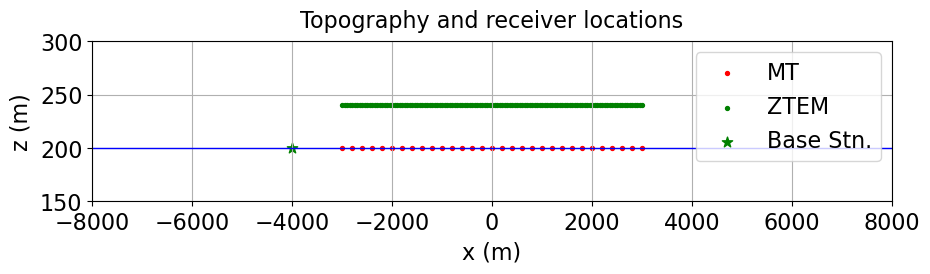

In [6]:
fig = plt.figure(figsize=(10, 2))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(locations_x_mt, locations_z_mt, 8, "r")
ax.scatter(locations_x_ztem, locations_z_ztem, 8, "g")
ax.scatter(location_x_base, location_z_base, 60, "g", marker="*")
ax.plot(x_topo, z_topo, color="b", linewidth=1)
ax.set_xlim([x_topo.min(), x_topo.max()])
ax.set_ylim([z_topo.min()-50, z_topo.max()+100])
ax.set_xlabel("x (m)", labelpad=5)
ax.set_ylabel("z (m)", labelpad=5)
ax.grid(True)
ax.set_title("Topography and receiver locations", fontsize=16, pad=10)
ax.legend(['MT', 'ZTEM', 'Base Stn.'])
plt.show(fig)

## Define the Mesh, Model, and Mapping

## Design a (Tree) Mesh

Meshes are designed using the [discretize](https://discretize.simpeg.xyz/en/main) package. See the [discretize user tutorials](https://discretize.simpeg.xyz/en/main/tutorials/mesh_generation/index.html) to learn more about creating meshes.
Here, the forward simulation is computed for a [tree mesh](xref:discretize#discretize.TreeMesh). Because of the modular nature of SimPEG, you could define a [tensor mesh](xref:discretize#discretize.TensorMesh) instead.

**Standard approach for NSEM:** 

1) *Minimum cell thickness:* depends on the minimum skin depth for your simulation. Where $f_{max}$ is the highest frequency being simulation and $\sigma_{max}$ is the conductivity of the most conductive structure, the minimum skin depth is given by:
\begin{equation}
d_{min} \approx 500 \sqrt{\dfrac{1}{\sigma_{max} \, f_{max}}}
\end{equation}
The minimum cell thickness **must** be at least a factor 4 smaller than the minimum skin depth, i.e.:
\begin{equation}
\Delta z_{min} \leq \frac{d_{min}}{4}
\end{equation}

3) *Minimum cell width:* can be set to equal the minimum cell thickness, resulting in square cells. Since the source is an incoming planewave, which is smooth in the horizontal, the minimum cell width is sometimes set as 2x larger than the minimum cell thickness. Generally for EM problems, one does not want to exceed a 2 to 1 aspect ratio for mesh cells. If generating a mesh for inversion, we need at least 3 cells between each receiver. Finer discretization is necessary when topography is significant.

4) *Discretization within the survey region:* Here, the smallest cell side is used near the surface. The cell size can be increased at depths where highest frequencies are not longer expected to have sufficient penetration depth. It is important not to increase the cell size too quickly. You should have a layer at least 4 cells thick before increasing the cell size again.

5) *Padding:* The natural boundary conditions for NSEM simulations in SimPEG is the solution to a 1D wave equation. Essentially, we assume the anomalous fields from 3D structures and topography are zero at the boundary. The distance we must pad out depends on the largest skin depth, i.e.:
\begin{equation}
d_{min} \approx 500 \sqrt{\dfrac{1}{\sigma_{min} \, f_{min}}}
\end{equation}
where $f_{min}$ is the lowest frequency being simulation and $\sigma_{min}$ is the conductivity of the least conductive structure. Unlike controlled sources, planewave sources do not experience geometric decay. To be safe, the padding region should be at least 4 times the largest skin depth. With OcTree meshing, this does not add many extra cells. When topography is present, it is important not do coarsen the mesh near the surface too quickly when simulating airborne data. Having large vertical interfaces between air and ground cells generates anomalous magnetic fields which may contaminate airborne data.

**Tutorial mesh:** Here, a minimum cell thickness and cell width of 5 m (or 1/10 the minimum skin depth) is used within our survey region. This is much smaller than any of the station spacings. We use the [refine_surface](xref:discretize#discretize.TreeMesh.refine_surface) method to refine the tree mesh based on topography. We do a coarser refinement over the entire defined topography, and we do a fine refinement within the survey region. We use the [refine_points](xref:discretize#discretize.TreeMesh.refine_points) method to refine at the locations where fields are measured. The padding is at least 6x the maximum skin depth. Visit the [tree mesh](xref:discretize#discretize.TreeMesh) API to see additional refinement methods.

:::{tip}
For a flatter surface topography as one approaches the boundary, try shifting the vertical position of the mesh so that the middle lines up with the elevation of your surface topography in the survey region.
:::

In [7]:
# Minimum skin depth
500. / np.sqrt(frequencies_mt.max() * block_conductivity)

50.0

In [8]:
# Maximum skin depth
500. / np.sqrt(frequencies_mt.min() * basement_conductivity)

1581.1388300841895

In [9]:
dh = 5  # base cell width
dom_width_x = 40000.0  # domain width x
dom_width_z = 40000.0  # domain width z
nbcx = 2 ** int(np.round(np.log(dom_width_x / dh) / np.log(2.0)))  # num. base cells x
nbcz = 2 ** int(np.round(np.log(dom_width_z / dh) / np.log(2.0)))  # num. base cells z

# Define the base mesh with top at z = 0 m.
hx = [(dh, nbcx)]
hz = [(dh, nbcz)]
mesh = TreeMesh([hx, hz], x0="CC", diagonal_balance=True)

# Shift vertically by maximum topography
mesh.origin = mesh.origin + np.r_[0.0, z_topo.max()]

# Coarse mesh refinement based on topography
mesh.refine_surface(
    topo_2d,
    padding_cells_by_level=[0, 0, 0, 4, 4, 8, 8],
    finalize=False,
)

# Mesh refinement for core region
inds = (topo_2d[:, 0] > -3200.) & (topo_2d[:, 0] < 3200.)
mesh.refine_surface(
    topo_2d[inds, :],
    padding_cells_by_level=[10, 10, 10, 6, 6, 6, 4],
    finalize=False,
)

# Refine around receiver locations
pts = np.vstack(
    [locations_mt, locations_ztem, location_base]
)
mesh.refine_points(
    pts, padding_cells_by_level=[6, 6, 6, 4, 4], finalize=False
)

mesh.finalize()

In [10]:
mesh.n_cells

68794

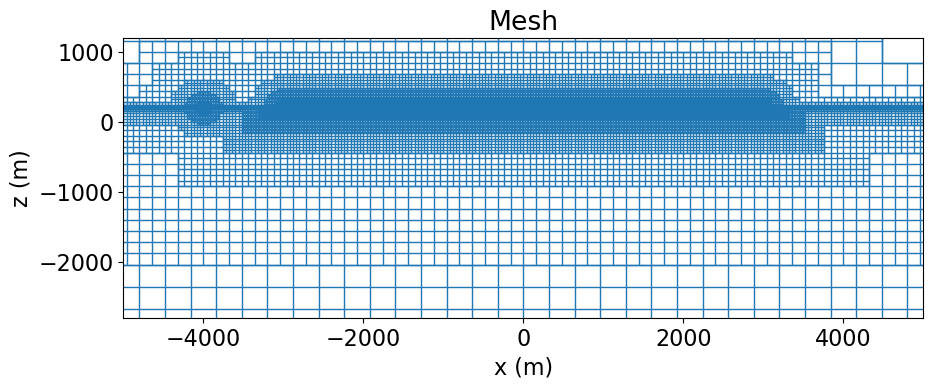

In [11]:
fig = plt.figure(figsize=(10, 4))

ax1 = fig.add_axes([0.14, 0.17, 0.8, 0.7])
mesh.plot_grid(ax=ax1, linewidth=1)
ax1.grid(False)
ax1.set_xlim(-5000, 5000)
ax1.set_ylim(np.max(z_topo) - 3000, np.max(z_topo)+1000)
ax1.set_title("Mesh")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")

plt.show()

## Define the Active Cells

Simulated geophysical data are dependent on the subsurface distribution of physical property values. As a result, the cells lying below the surface topography are commonly referred to as 'active cells'. And air cells, whose physical property values are fixed, are commonly referred to as 'inactive cells'. Here, the discretize [active_from_xyz](xref:discretize#discretize.utils.active_from_xyz) utility function is used to find the indices of the active cells using the mesh and surface topography. The output quantity is a ``bool`` array.

In [12]:
# Indices of the active mesh cells from topography (e.g. cells below surface)
active_cells = active_from_xyz(mesh, topo_2d)

# number of active cells
n_active = np.sum(active_cells)

## Models and Mappings

In SimPEG, the term 'model' is not necessarily synonymous with the set of physical property values defined on the mesh. For example, the model may be defined as the logarithms of the physical property values, or be the parameters defining a layered Earth geometry. Models in SimPEG are 1D [numpy.ndarray](xref:numpy#numpy.ndarray) whose lengths are equal to the number of model parameters.

Classes within the [simpeg.maps](xref:simpeg#simpeg.maps.IdentityMap) module are used to define the mapping that connects the model to the physical property values used in the NSEM simulation. Sophisticated mappings can be defined by combining multiple mapping objects. In the simplest case, the mapping is an identity map and the model consists of the conductivity/resistivity values for all mesh cells (including air).

### Define the Model

When simulating NSEM data, we have the choice of using resistivity or conductivity to define the Earth's electrical properties. The units for resistivity are $\Omega m$ and the units for conductivity are $S/m$.

**For the tutorial,** the model parameters are the conductivities for all mesh cells lying below the surface topography (active cells).

In [13]:
# Define conductivity model
conductivity_model = host_conductivity * np.ones(n_active)

ind_basement = mesh.cell_centers[active_cells, -1] < basement_elevation
conductivity_model[ind_basement] = basement_conductivity

ind_block = model_builder.get_indices_block(
    block_corner_1, block_corner_2, mesh.cell_centers[active_cells, :]
)
conductivity_model[ind_block] = block_conductivity

C:\Users\devin\AppData\Local\Temp\ipykernel_22756\261260649.py:7: BreakingChangeWarning: Since SimPEG v0.25.0, the 'get_indices_block' function returns a single array with the cell indices, instead of a tuple with a single element. This means that we don't need to unpack the tuple anymore to access to the cell indices.
If you were using this function as in:

    ind = get_indices_block(p0, p1, mesh.cell_centers)[0]

Make sure you update it to:

    ind = get_indices_block(p0, p1, mesh.cell_centers)

To hide this warning, add this to your script or notebook:

    import warnings
    from simpeg.utils import BreakingChangeWarning

    warnings.filterwarnings(action='ignore', category=BreakingChangeWarning)

  ind_block = model_builder.get_indices_block(


### Define the Mapping

Our model is the electrical conductivities of all active cells in the mesh. We use the [simpeg.maps.InjectActiveCells](xref:simpeg#simpeg.maps.InjectActiveCells) mapping to map the model parameters to the mesh, and to set a constant value for all inactive cells.
 
**Important:** we set all inactive (air) cells to 1e-8 S/m instead of 0. This is done to ensure that the linear system constructed to solve the PDE for the problem is well-conditioned.

In [14]:
conductivity_map = maps.InjectActiveCells(mesh, active_cells, air_conductivity)

### Plot the Model

To show the geometry of the problem, we plot the conductivity model using the [plot_image](xref:discretize#discretize.TreeMesh.plot_image) method.

In [15]:
# Generate a mapping to ignore inactice cells in plot
plotting_map = maps.InjectActiveCells(mesh, active_cells, np.nan)

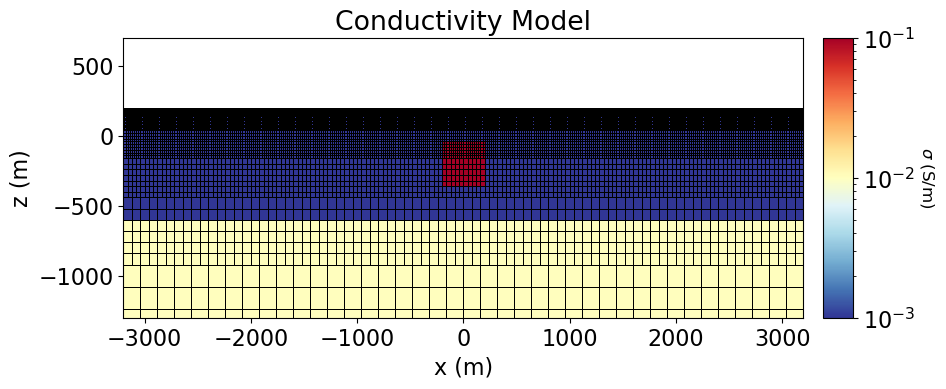

In [16]:
fig = plt.figure(figsize=(10, 4))

norm = LogNorm(vmin=1e-3, vmax=1e-1)

ax1 = fig.add_axes([0.14, 0.17, 0.68, 0.7])
mesh.plot_image(
    plotting_map * conductivity_model,
    ax=ax1,
    grid=True,
    pcolor_opts={"norm": norm, "cmap": mpl.cm.RdYlBu_r},
    grid_opts={"color":"k", "linewidth": 0.5}
)
ax1.set_xlim(-3200, 3200)
ax1.set_ylim(np.max(z_topo) - 1500, np.max(z_topo)+500)
ax1.set_title("Conductivity Model")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")

ax2 = fig.add_axes([0.84, 0.17, 0.03, 0.7])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.RdYlBu_r
)
cbar.set_label(r"$\sigma$ (S/m)", rotation=270, labelpad=15, size=12)

plt.show()

## Define a Background Conductivity Model

A necessary step for 2D and 3D NSEM simulation is the definition of a background conductivity model. The background conductivity model is used to compute the fields for a simplified problem geometry, which are then used to set the boundary conditions for solving the 2D or 3D problem. Here, we define a 1D background conductivity model.

**For the tutorial,** the 1D background conductivity model consists of two layers.

:::{attention}
When topography is significant, take a look at your 3D conductivity model at the boundaries. If you have padded out sufficiently, the discrete surface topography should meet the boundaries at the same elevation. This elevation should be used to denote the air-Earth interface for the 1D model.
:::

In [17]:
# Define 1D mesh using vertical discretization of the 2D/3D mesh
hz_1d = mesh.h[-1]
mesh_1d = TensorMesh([hz_1d], origin=np.array([mesh.origin[-1]]))

# Assign conductivity values
sigma_1d = air_conductivity * np.ones(mesh_1d.n_cells)
sigma_1d[mesh_1d.cell_centers < z_topo.max()] = host_conductivity
sigma_1d[mesh_1d.cell_centers < basement_elevation] = basement_conductivity

## Simulate Impedance Data

### Shift to Discrete Topography

Ground impedance data will not be modeled accurately if the receivers are modeled as living above or below the surface. It is especially problematic when receivers modeled as living in the air. Prior to simulating surface MT data, we must project the receivers from their true elevation to the surface of the discretized topography. This is done using the [shift_to_discrete_topography](xref:simpeg#simpeg.utils.shift_to_discrete_topography) utility function.

**For the tutorial,** this step isn't exactly necessary since the topography is flat and MT stations were defined directly on the surface.

In [18]:
locations_mt_shifted = shift_to_discrete_topography(
    mesh,
    locations_mt,
    active_cells,
    topo_cell_cutoff='top',
    shift_horizontal=True,
    heights=0.
)

### Survey

To generate a 2D NSEM survey, the user must create and connect three types of objects:

- **receivers:** which define the locations of the NSEM fields being measured and the data type; see the [Impedance](xref:simpeg#simpeg.electromagnetics.natural_source.receivers.Impedance), [Tipper](xref:simpeg#simpeg.electromagnetics.natural_source.receivers.Tipper), and [Admittance](xref:simpeg#simpeg.electromagnetics.natural_source.receivers.Admittance) classes.
- **sources:** which defines the frequencies of the incident planewave source. For a 2D problem geometry, we use the [Fictitious](xref:simpeg#simpeg.electromagnetics.static.natural_source.source.FictitiousSource) class. Whether the source refers to the TE or TM mode is determined by the simulation class.
- **survey:** which uses the [survey](xref:simpeg#simpeg.electromagnetics.natural_source.Survey) class to store and organizes all of the sources and receivers.

**For this tutorial**, we simulate all the data types corresponding to the $Z_{xy}$ and $Z_{yx}$ impedances: the real component of the impedance (V/A), the imaginary component (V/A), the apparent resistivity ($\Omega m$) and the phase (deg). Data are simulated at 7 logarithmically spaced frequencies between 10 Hz and 1000 Hz.

For a 2D problem geometry, $Z_{xy}$ and $Z_{yx}$ data cannot be simulated using the same simulation class. In SimPEG, $Z_{xy}$ results from the TE mode, which requires a numerical solution for an incoming planewave whose electric field is polarized along the x-direction. $Z_{yx}$ results from the TM mode, which requires a numerical solution for an incoming planewave whose magnetic field is polarized along the x-direction. Consequently, we define separate survey objects for $Z_{xy}$ and $Z_{yx}$ data while will be computed using separate simulation classes.

In [19]:
source_list_e = []
source_list_h = []

# First loop over frequencies
for freq in frequencies_mt:
    
    receiver_list_e = []
    receiver_list_h = []

    # Next loop over receiver types
    for comp in ['real', 'imag', 'app_res', 'phase']:
        # Locations of corresponding electric and magnetic
        # field measurements set separately
        receiver_list_e.append(
            nsem.receivers.Impedance(
                locations_e=locations_mt_shifted,
                locations_h=locations_mt_shifted,
                orientation='xy',
                component=comp,
            )
        )
        receiver_list_h.append(
            nsem.receivers.Impedance(
                locations_e=locations_mt_shifted,
                locations_h=locations_mt_shifted,
                orientation='yx',
                component=comp,
            )
        )

    source_list_e.append(
        nsem.sources.FictitiousSource(
            receiver_list=receiver_list_e, frequency=freq,
        )
    )
    source_list_h.append(
        nsem.sources.FictitiousSource(
            receiver_list=receiver_list_h, frequency=freq,
        )
    )

survey_e = nsem.survey.Survey(source_list_e)
survey_h = nsem.survey.Survey(source_list_h)

### Define the Forward Simulation

In SimPEG, the physics of the forward simulation is defined by creating an instance of an appropriate simulation class. For 2D NSEM problems, there are 2 simulation classes:

- [Simulation2DElectricFieldFictitious](xref:simpeg#simpeg.electromagnetics.natural_source.Simulation2DElectricFieldFictitious), which defines the electric fields on mesh edges. This class is used to simulate data types corresponding to the TE mode: impedance $Z_{xy}$ and admittance $Y_{yx}$
- [Simulation2DMagneticFieldFictitious](xref:simpeg#simpeg.electromagnetics.natural_source.Simulation2DMagneticFieldFictitious), which defines the magnetic fields on mesh edges. This class is used to simulate data types corresponding to the TM mode: impedance $Z_{yx}$, tipper $T_{zx}$ and admittance $Y_{xy}$

To fully define the forward simulation, we need to connect the simulation object to:

- the mesh
- the survey
- the background conductivity model
- the mapping from the model to the mesh
- the solver

This is accomplished by setting each one of the aforementioned items as a property of the simulation object. Here, we define two simulation objects, one for the TE mode (electric field) and one for the TM mode (magnetic field). The mapping is set using the ``sigmaMap`` keyword argument.

In [20]:
simulation_e = nsem.simulation.Simulation2DElectricFieldFictitious(
    mesh,
    survey=survey_e,
    sigma_background=sigma_1d,
    sigmaMap=conductivity_map,
    solver=get_default_solver()
)

simulation_h = nsem.simulation.Simulation2DMagneticFieldFictitious(
    mesh,
    survey=survey_h,
    sigma_background=sigma_1d,
    sigmaMap=conductivity_map,
    solver=get_default_solver()
)

### Predict and Sort MT Data

Once any simulation within SimPEG has been properly constructed, simulated data for a given model vector can be computed using the [dpred](xref:simpeg#simpeg.simulation.BaseSimulation.dpred) method.

In [21]:
dpred_e = simulation_e.dpred(conductivity_model)
dpred_h = simulation_h.dpred(conductivity_model)

The data vector output by the simulation is order by freqency, receiver, then location. Here, we reshape the data into a three-dimensional array for easy indexing.

In [22]:
n_comp = 4  # number of receiver types
Zxy = np.reshape(dpred_e, (len(frequencies_mt), n_comp, len(locations_x_mt)))
Zyx = np.reshape(dpred_h, (len(frequencies_mt), n_comp, len(locations_x_mt)))

### Plot MT Data

We stated that SimPEG uses an Easting-Northing-Up convention with a $+i\omega t$ Fourier convention. As a result, $Z_{xy}$ impedances are in the bottom-left coordinate of the complex plane, and $Z_{yx}$ impedances are in the top-right.

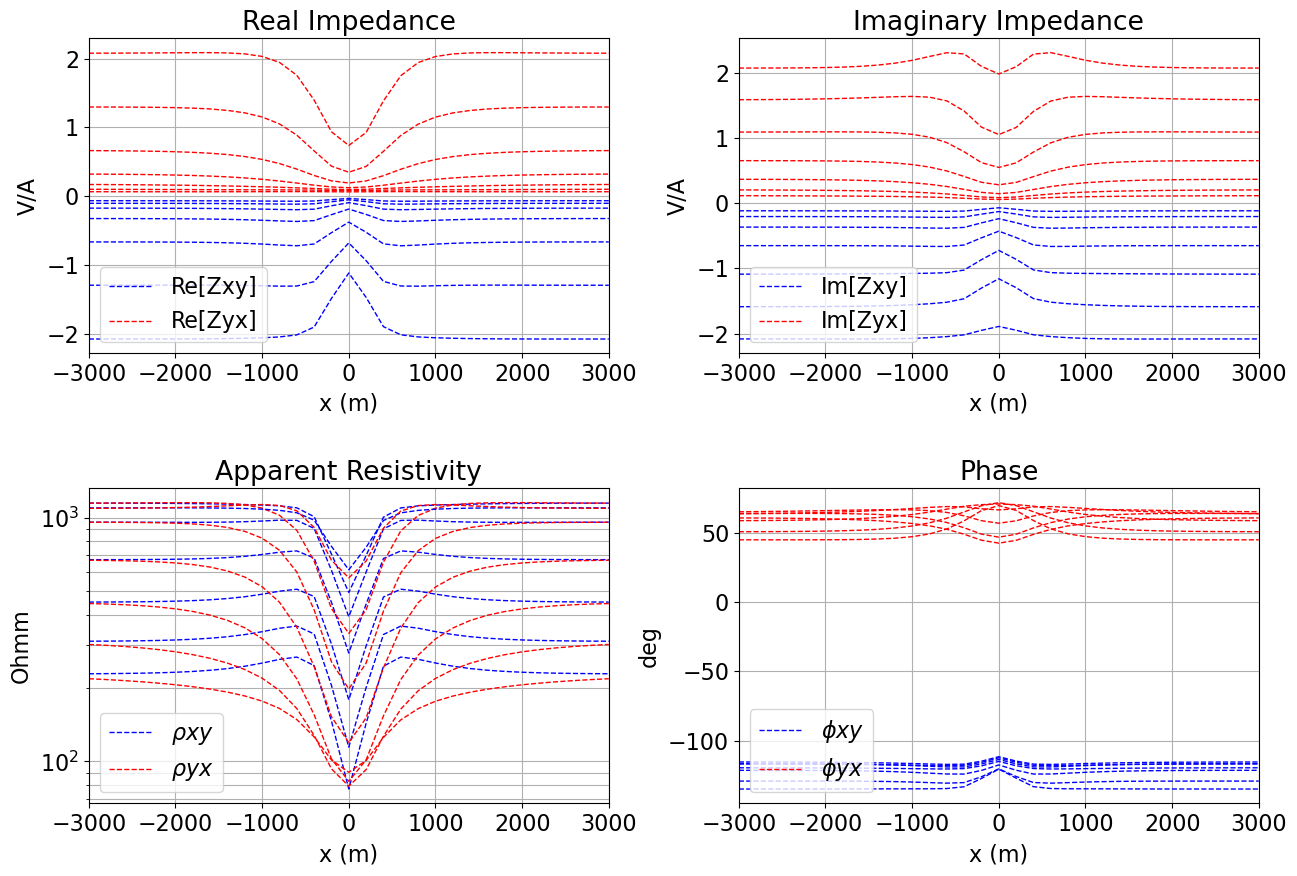

In [30]:
fig = plt.figure(figsize=(13, 9))

ax = 4 * [None]
COUNT = 0

# comp_str = [

for ii in range(2):
    for jj in range(2):
        ax[COUNT] = fig.add_axes([0.1+0.5*jj, 0.6-0.5*ii, 0.4, 0.35])
        for kk in range(len(frequencies_mt)):
            if COUNT == 2:
                ax[COUNT].semilogy(locations_x_mt, Zxy[kk, COUNT, :].T, 'b--', lw=1)
                ax[COUNT].semilogy(locations_x_mt, Zyx[kk, COUNT, :].T, 'r--', lw=1)
            else:
                ax[COUNT].plot(locations_x_mt, Zxy[kk, COUNT, :].T, 'b--', lw=1)
                ax[COUNT].plot(locations_x_mt, Zyx[kk, COUNT, :].T, 'r--', lw=1)

        ax[COUNT].set_xlim([locations_x_mt.min(), locations_x_mt.max()])
        ax[COUNT].set_xlabel("x (m)", labelpad=5)
        ax[COUNT].grid(which='both')
        
        if COUNT == 0:
            ax[COUNT].set_ylabel("V/A", labelpad=5)
            ax[COUNT].set_title("Real Impedance")
            ax[COUNT].legend(['Re[Zxy]', 'Re[Zyx]'], loc='lower left')
        elif COUNT == 1:
            ax[COUNT].set_ylabel("V/A", labelpad=5)
            ax[COUNT].set_title("Imaginary Impedance")
            ax[COUNT].legend(['Im[Zxy]', 'Im[Zyx]'], loc='lower left')
        elif COUNT == 2:
            ax[COUNT].set_ylabel("Ohmm", labelpad=5)
            ax[COUNT].set_title("Apparent Resistivity")
            ax[COUNT].legend(['$\\rho xy$', '$\\rho yx$'], loc='lower left')
        elif COUNT == 3:
            ax[COUNT].set_ylabel("deg", labelpad=5)
            ax[COUNT].set_title("Phase")
            ax[COUNT].legend(['$\\phi xy$', '$\\phi yx$'], loc='lower left')
        COUNT = COUNT + 1

plt.show(fig)

## Simulate Airborne Tipper Data

### Shift to Discrete Topography

Airborne tippers are less influenced by the errors attributed to discrete topography compared to ground impedances. Airborne tippers are driven by anomalous magnetic fields while ground impedances are primarily driven by anomalous electric fields. However, users may want to preserve the original flight height of tipper measurements relative to the discrete topography. We can generated a shifted set of airborne tipper locations that preserve the original flight height using the [shift_to_discrete_topography](xref:simpeg#simpeg.utils.shift_to_discrete_topography) utility function.

**For the tutorial,** this step isn't exactly necessary since the topography is flat and MT stations were defined directly on the surface.

In [24]:
# Find the discrete topography and adds the original flight height
locations_ztem_shifted = shift_to_discrete_topography(
    mesh,
    locations_ztem,
    active_cells,
    topo_cell_cutoff='top',
    shift_horizontal=False,
    heights=flight_height
)

# Place the base station directly on the discrete topography
locations_base_shifted = shift_to_discrete_topography(
    mesh,
    location_base,
    active_cells,
    topo_cell_cutoff='top',
    shift_horizontal=True,
    heights=0
)
locations_base_shifted = np.repeat(locations_base_shifted, len(locations_ztem), axis=0)

### Survey

To generate a 2D NSEM survey, the user must create and connect three types of objects:

- **receivers:** which define the locations of the NSEM fields being measured and the data type; see the [Impedance](xref:simpeg#simpeg.electromagnetics.natural_source.receivers.Impedance), [Tipper](xref:simpeg#simpeg.electromagnetics.natural_source.receivers.Tipper), and [Admittance](xref:simpeg#simpeg.electromagnetics.natural_source.receivers.Admittance) classes.
- **sources:** which defines the frequencies of the incident planewave source. For a 2D problem geometry, we use the [Fictitious](xref:simpeg#simpeg.electromagnetics.static.natural_source.source.FictitiousSource) class. Whether the source refers to the TE or TM mode is determined by the simulation class.
- **survey:** which uses the [survey](xref:simpeg#simpeg.electromagnetics.natural_source.Survey) class to store and organizes all of the sources and receivers.

**For this tutorial**, we simulate the real and imaginary components of the $T_{zx}$ tipper at 7 logarithmically spaced frequencies between 10 Hz and 1000 Hz. For a 2D problem geometry, tipper anomalies are only produced by the TM mode. As a result, we can only simulate $T_{zx}$ data.

In [25]:
source_list_ztem = []  

for freq in frequencies_ztem:

    receiver_list_ztem = []
    for comp in ['real', 'imag']:
        # Shape of locations_h must match shape of loactions_base.
        # This allows for AFMag or multiple base stations.
        receiver_list_ztem.append(
            nsem.receivers.Tipper(
                locations_h=locations_ztem_shifted,
                locations_base=locations_base_shifted,
                orientation='zx',
                component=comp,
            )
        )

    source_list_ztem.append(
        nsem.sources.FictitiousSource(
            receiver_list=receiver_list_ztem, frequency=freq,
        )
    )

survey_ztem = nsem.survey.Survey(source_list_ztem)

### Define the Forward Simulation

Since only the TM mode produces tippers, we use the [Simulation2DMagneticFieldFictitious](xref:simpeg#simpeg.electromagnetics.natural_source.Simulation2DMagneticFieldFictitious) simulation class.

In [26]:
simulation_ztem = nsem.simulation.Simulation2DMagneticFieldFictitious(
    mesh,
    survey=survey_ztem,
    sigma_background=sigma_1d,
    sigmaMap=conductivity_map,
    solver=get_default_solver()
)

### Simulate and Sort the Data

In [27]:
dpred_ztem = simulation_ztem.dpred(conductivity_model)

In [28]:
n_comp = 2
Tzx = np.reshape(dpred_ztem, (len(frequencies_ztem), n_comp, len(locations_x_ztem)))

### Plot the Tipper Data

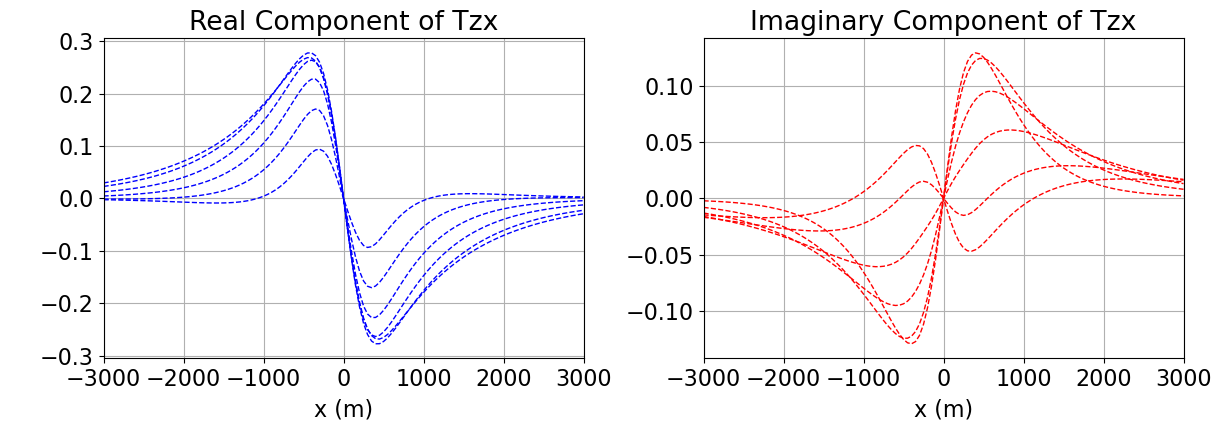

In [29]:
fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_axes([0.1, 0.1, 0.4, 0.8])
ax2 = fig.add_axes([0.6, 0.1, 0.4, 0.8])

ax1.plot(locations_x_ztem, Tzx[:, 0, :].T, 'b--', lw=1)
ax1.set_xlim([locations_x_ztem.min(), locations_x_ztem.max()])
ax1.set_xlabel("x (m)", labelpad=5)
ax1.set_ylabel(" ", labelpad=5)
ax1.grid(which='both')
ax1.set_title("Real Component of Tzx")

ax2.plot(locations_x_ztem, Tzx[:, 1, :].T, 'r--', lw=1)
ax2.set_xlim([locations_x_ztem.min(), locations_x_ztem.max()])
ax2.set_xlabel("x (m)", labelpad=5)
ax2.set_ylabel(" ", labelpad=5)
ax2.grid(which='both')
ax2.set_title("Imaginary Component of Tzx")

plt.show(fig)